Starting Run 1 (alpha = 0.005, epochs = 20)
Epoch 1 -> MSE: 3250.6 | w1: 2.86 | w2: 3.31 | b: 0.53
Epoch 4 -> MSE: 264.19 | w1: 5.05 | w2: 4.35 | b: 0.76
Epoch 8 -> MSE: 165.37 | w1: 6.17 | w2: 3.66 | b: 0.75
Epoch 12 -> MSE: 105.31 | w1: 7.03 | w2: 3.07 | b: 0.73
Epoch 16 -> MSE: 67.27 | w1: 7.72 | w2: 2.59 | b: 0.71
Epoch 20 -> MSE: 43.19 | w1: 8.26 | w2: 2.21 | b: 0.7


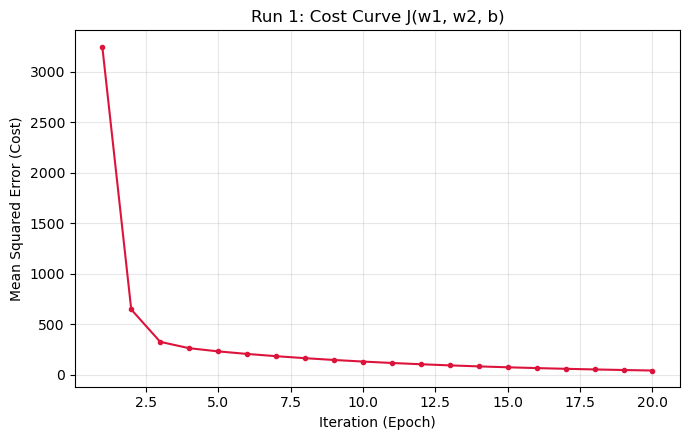

([np.float64(3250.6),
  np.float64(647.3059279780798),
  np.float64(327.1709129599288),
  np.float64(264.186409458052),
  np.float64(232.74791184039276),
  np.float64(207.45412842270707),
  np.float64(185.19632520213173),
  np.float64(165.37492814472748),
  np.float64(147.69673598222306),
  np.float64(131.92706107377597),
  np.float64(117.85953381025188),
  np.float64(105.31039119246478),
  np.float64(94.11574161788887),
  np.float64(84.12938724372279),
  np.float64(75.22091056093336),
  np.float64(67.27397073688012),
  np.float64(60.18478420287745),
  np.float64(53.86076927975798),
  np.float64(48.21933710035495),
  np.float64(43.18681303437113)],
 np.float64(8.264860543462952),
 np.float64(2.2141616059905895),
 np.float64(0.7024631247006486))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset with two features: x1 = Study Hours, x2 = Sleep Hours
x1 = np.array([1.5, 2.0, 2.5, 3.2, 4.0, 5.0, 5.5, 6.5, 7.2, 8.0])
x2 = np.array([8.5, 8.0, 7.5, 7.0, 7.0, 6.5, 6.0, 6.0, 5.5, 5.0])
y  = np.array([22.0, 28.0, 31.0, 40.0, 48.0, 56.0, 65.0, 72.0, 78.0, 88.0])
m_samples = len(y)


def run_multiple_gradient_descent(learning_rate, epochs, run_name="Run"):
    # Initialize parameters to 0
    w1 = 0.0
    w2 = 0.0
    b = 0.0

    cost_history = []

    print("=" * 55)
    print("Starting " + run_name + " (alpha = " + str(learning_rate) +
          ", epochs = " + str(epochs) + ")")
    print("=" * 55)

    for epoch in range(1, epochs + 1):
        # 1. Multiple Linear Regression Prediction: y_hat = w1*x1 + w2*x2 + b
        y_pred = (w1 * x1) + (w2 * x2) + b

        # 2. Residual Error: error = y_actual - y_predicted
        error = y - y_pred

        # 3. Cost Function (MSE): J = (1/m) * sum(error^2)
        mse = np.mean(error ** 2)
        cost_history.append(mse)

        # Stop early if the learning rate causes values to blow up
        if np.isnan(mse) or mse > 1e7:
            print("Epoch " + str(epoch) + ": Error exploded! Learning rate is too high.")
            break

        # 4. Compute Gradients for w1, w2, and b
        dj_dw1 = (-2.0 / m_samples) * np.sum(x1 * error)
        dj_dw2 = (-2.0 / m_samples) * np.sum(x2 * error)
        dj_db  = (-2.0 / m_samples) * np.sum(error)

        # 5. Gradient Descent Parameter Updates
        w1 = w1 - (learning_rate * dj_dw1)
        w2 = w2 - (learning_rate * dj_dw2)
        b  = b  - (learning_rate * dj_db)

        # Display progress at intervals
        if epoch == 1 or epoch == epochs or epoch % max(1, (epochs // 5)) == 0:
            print("Epoch " + str(epoch) +
                  " -> MSE: " + str(round(mse, 2)) +
                  " | w1: " + str(round(w1, 2)) +
                  " | w2: " + str(round(w2, 2)) +
                  " | b: " + str(round(b, 2)))

    # Plot Cost Curve (Loss vs Iterations)
    plt.figure(figsize=(7, 4.5))
    plt.plot(range(1, len(cost_history) + 1), cost_history,
             color="crimson", marker="o", markersize=3)
    plt.title(run_name + ": Cost Curve J(w1, w2, b)")
    plt.xlabel("Iteration (Epoch)")
    plt.ylabel("Mean Squared Error (Cost)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return cost_history, w1, w2, b


# --- RUN EXPERIMENTS ---
# Run 1: Base Run
run_multiple_gradient_descent(learning_rate=0.005, epochs=20, run_name="Run 1")



Starting Run 2 (alpha = 0.005, epochs = 100)
Epoch 1 -> MSE: 3250.6 | w1: 2.86 | w2: 3.31 | b: 0.53
Epoch 20 -> MSE: 43.19 | w1: 8.26 | w2: 2.21 | b: 0.7
Epoch 40 -> MSE: 5.83 | w1: 9.71 | w2: 1.21 | b: 0.67
Epoch 60 -> MSE: 2.03 | w1: 10.17 | w2: 0.89 | b: 0.66
Epoch 80 -> MSE: 1.64 | w1: 10.32 | w2: 0.79 | b: 0.66
Epoch 100 -> MSE: 1.6 | w1: 10.37 | w2: 0.76 | b: 0.66


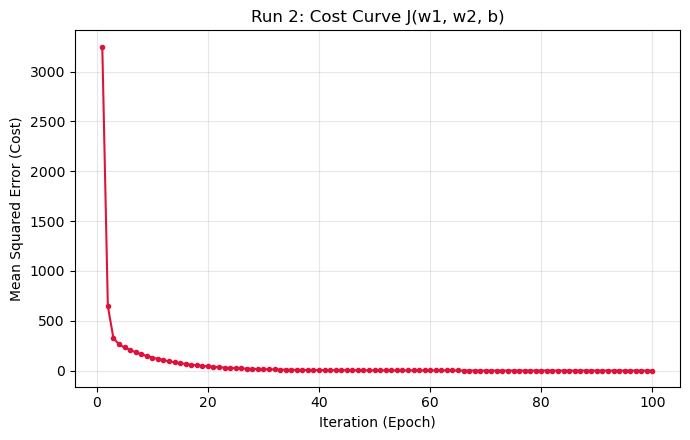

([np.float64(3250.6),
  np.float64(647.3059279780798),
  np.float64(327.1709129599288),
  np.float64(264.186409458052),
  np.float64(232.74791184039276),
  np.float64(207.45412842270707),
  np.float64(185.19632520213173),
  np.float64(165.37492814472748),
  np.float64(147.69673598222306),
  np.float64(131.92706107377597),
  np.float64(117.85953381025188),
  np.float64(105.31039119246478),
  np.float64(94.11574161788887),
  np.float64(84.12938724372279),
  np.float64(75.22091056093336),
  np.float64(67.27397073688012),
  np.float64(60.18478420287745),
  np.float64(53.86076927975798),
  np.float64(48.21933710035495),
  np.float64(43.18681303437113),
  np.float64(38.69747452940832),
  np.float64(34.69269280271676),
  np.float64(31.120167174526195),
  np.float64(27.933242043676938),
  np.float64(25.09029758554846),
  np.float64(22.55420621506225),
  np.float64(20.291847716399804),
  np.float64(18.273676707238533),
  np.float64(16.473336788774063),
  np.float64(14.867316342495636),
  np.flo

In [2]:
# Run 2: Deeper run
run_multiple_gradient_descent(learning_rate=0.005, epochs=100, run_name="Run 2")

Starting Run 3 (alpha = 0.0001, epochs = 20)
Epoch 1 -> MSE: 3250.6 | w1: 0.06 | w2: 0.07 | b: 0.01
Epoch 4 -> MSE: 3024.99 | w1: 0.22 | w2: 0.26 | b: 0.04
Epoch 8 -> MSE: 2750.84 | w1: 0.44 | w2: 0.5 | b: 0.08
Epoch 12 -> MSE: 2504.3 | w1: 0.64 | w2: 0.74 | b: 0.12
Epoch 16 -> MSE: 2282.56 | w1: 0.84 | w2: 0.95 | b: 0.15
Epoch 20 -> MSE: 2083.1 | w1: 1.02 | w2: 1.16 | b: 0.19


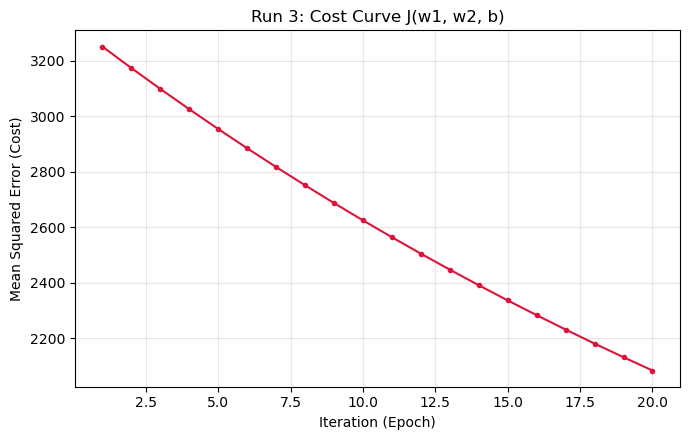

([np.float64(3250.6),
  np.float64(3173.3908400919913),
  np.float64(3098.2069430379106),
  np.float64(3024.994713380145),
  np.float64(2953.701975037665),
  np.float64(2884.2779337141174),
  np.float64(2816.6731403015356),
  np.float64(2750.839455253305),
  np.float64(2686.7300139006975),
  np.float64(2624.29919268801),
  np.float64(2563.5025763019516),
  np.float64(2504.2969256716133),
  np.float64(2446.640146815955),
  np.float64(2390.4912605163613),
  np.float64(2335.8103727924245),
  np.float64(2282.5586461596677),
  np.float64(2230.6982716485127),
  np.float64(2180.192441564316),
  np.float64(2131.005322968858),
  np.float64(2083.102031864175)],
 np.float64(1.02498050771206),
 np.float64(1.1596682120711563),
 np.float64(0.18611675991033008))

In [3]:
# Run 3: Baby steps / Too small alpha
run_multiple_gradient_descent(learning_rate=0.0001, epochs=20, run_name="Run 3")


Starting Run 4 (alpha = 0.05, epochs = 20)
Epoch 1 -> MSE: 3250.6 | w1: 28.58 | w2: 33.15 | b: 5.28
Epoch 4: Error exploded! Learning rate is too high.


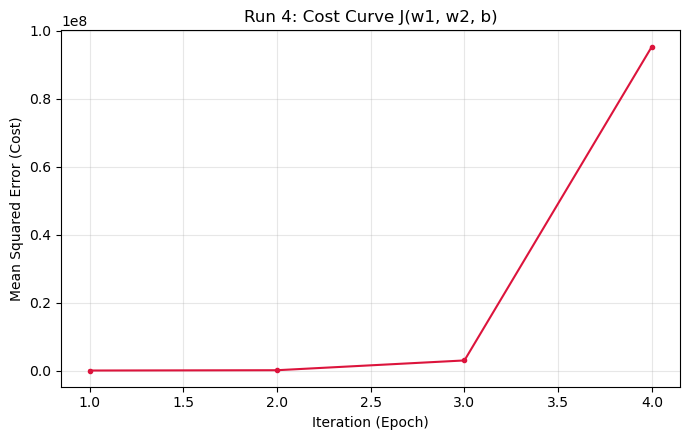

([np.float64(3250.6),
  np.float64(92671.488977808),
  np.float64(2972386.946242488),
  np.float64(95412552.841468)],
 np.float64(688.6626112526401),
 np.float64(975.381200436),
 np.float64(147.0262617632))

In [4]:
# Run 4: Too large alpha / Divergence
run_multiple_gradient_descent(learning_rate=0.05, epochs=20, run_name="Run 4")